### Data Generation for frustrated lattices (Heisenberg J1-J2 models)
This notebook provides examples and tests for modules `spin_lattices` and `heisenberg_hamiltonians`.

In [1]:
import black
import jupyter_black

jupyter_black.load(
    lab=False,
    line_length=79,
    target_version=black.TargetVersion.PY39,
)

<IPython.core.display.Javascript object>

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import lattice_symmetries as ls
import yaml
from heisenberg_hamiltonians import (
    make_unpacked_configurations,
    HeisenbergJ1J2,
)

from spin_lattices import (
    SpinLattice,
    ChainLattice,
    SquareLattice,
    KagomeLattice,
)

%matplotlib inline

#### Chain Lattice (1dim)

self.number_spins=12
Symmetry group contains 0 elements
Hilbert space dimension is 924
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-ChainLattice12x1-1.0-0.0-False-None-1.pickle
Ground state energy is -21.5495636698


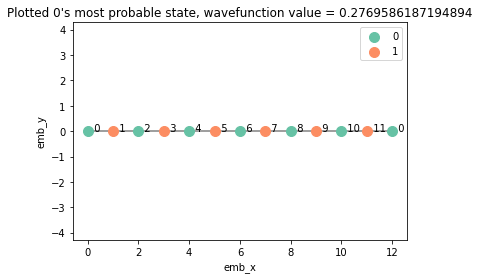

In [3]:
system_nosym = HeisenbergJ1J2(
    ChainLattice(width=12),
    J1=1,
    J2=0,
    use_symmetries=False,
    spin_inversion=None,
)
energy, state = system_nosym.get_eigenstates()
system_nosym.visualize_probable_configurations(m=0)

Antiferromagnetic, as expected

self.number_spins=12
Symmetry group contains 24 elements
Hilbert space dimension is 35
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-ChainLattice12x1-1.0-0.0-True-1-1.pickle
Ground state energy is -21.5495636698


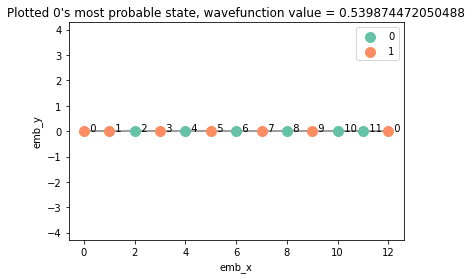

In [4]:
system_sym = HeisenbergJ1J2(
    ChainLattice(width=12), J1=1, J2=0, use_symmetries=True
)
energy, state = system_sym.get_eigenstates()
system_sym.visualize_probable_configurations(m=0, canonical_basis=False)

### NB
The “most probable configuration” is not physically defined: we change it when we take symmetries into account (collapse several events into one). So the result is different for calculations with symmetries and without them.

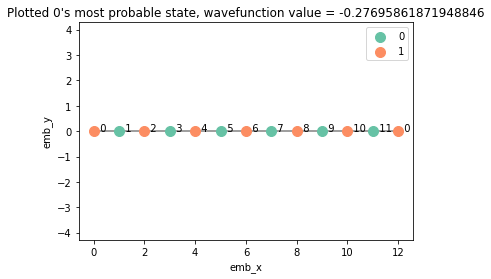

In [5]:
system_sym.visualize_probable_configurations(m=0, canonical_basis=True)

### Checks

#### 4×4 SquareLattice, J2=0

self.number_spins=16
Symmetry group contains 0 elements
Hilbert space dimension is 12870
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-SquareLattice4x4-1.0-0.0-False-None-1.pickle
Ground state energy is -44.9139328337


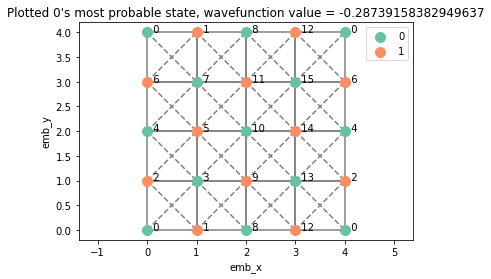

In [6]:
system_nosym = HeisenbergJ1J2(
    SquareLattice(width=4, height=4),
    J1=1,
    J2=0,
    use_symmetries=False,
    spin_inversion=None,
)
system_nosym.get_eigenstates()
system_nosym.visualize_probable_configurations(m=0)

The checkerboard, works as expected

self.number_spins=16
Symmetry group contains 128 elements
Hilbert space dimension is 107
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-SquareLattice4x4-1.0-0.0-True-1-1.pickle
Ground state energy is -44.9139328337


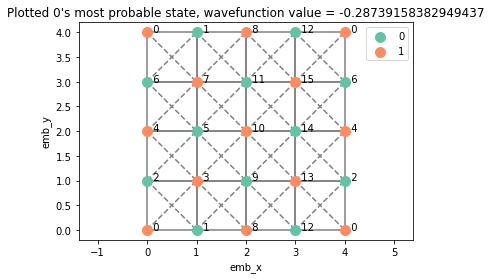

In [7]:
system_sym = HeisenbergJ1J2(
    SquareLattice(width=4, height=4), J1=1, J2=0, use_symmetries=True
)
system_sym.get_eigenstates()
system_sym.visualize_probable_configurations(m=0)

In [7]:
# with and without symmetries should give the same ground state energy
assert np.isclose(system_sym.ground_energy, system_nosym.ground_energy)

#### Reference 4×4

In [8]:
### FROM: https://github.com/twesterhout/nqs-playground/blob/0ba67c9d4ff9f70bbaeea2a9490271dd49ea5091/benchmark/benchmark_apply.py#L9-L20
def load_basis_and_hamiltonian(
    filename: str, no_symmetries=False, no_inversions=False
):
    import yaml

    # logger.info("Loading basis from '{}'...", filename)
    with open(filename, "r") as f:
        config = yaml.load(f, Loader=yaml.SafeLoader)
    if no_symmetries:
        config["basis"]["symmetries"] = []
    if no_inversions:
        del config["basis"]["spin_inversion"]
    basis = ls.SpinBasis.load_from_yaml(config["basis"])
    # logger.info("Loading Hamiltonian from '{}'...", filename)
    hamiltonian = ls.Operator.load_from_yaml(config["hamiltonian"], basis)
    return basis, hamiltonian


### END FROM

```
# Initial layout:
    # - permutation: [ 0,  1,  2,  3,
    #                  4,  5,  6,  7,
    #                  8,  9, 10, 11,
    #                 12, 13, 14, 15]
    #
```

In [9]:
basis, hamiltonian = load_basis_and_hamiltonian(
    "heisenberg_square_4x4.yaml", no_symmetries=True, no_inversions=True
)
eigenvalues, eigenstates = ls.diagonalize(hamiltonian, k=1)
assert np.isclose(eigenvalues[0], system_nosym.ground_energy)
# energy coincides with the reference implementation

#### 6×2 lattice 

self.number_spins=12
Symmetry group contains 0 elements
Hilbert space dimension is 462
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-SquareLattice6x2-1.0-0.0-False-1-1.pickle
Ground state energy is -41.2913023078


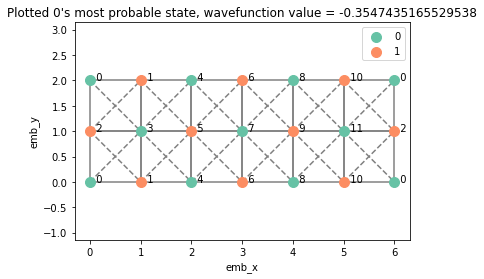

In [10]:
system_nosym = HeisenbergJ1J2(
    SquareLattice(width=6, height=2), J1=1, J2=0, use_symmetries=False
)
system_nosym.get_eigenstates()
system_nosym.visualize_probable_configurations(m=0)

The checkerboard, works as expected.

self.number_spins=12
Symmetry group contains 24 elements
Hilbert space dimension is 44
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-SquareLattice6x2-1.0-0.0-True-1-1.pickle
Ground state energy is -41.2913023078


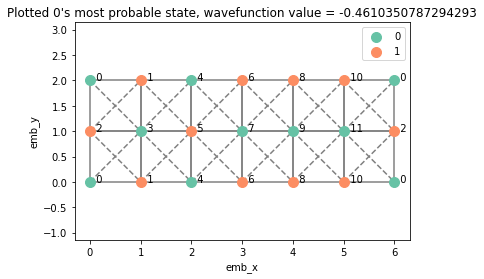

In [11]:
system_sym = HeisenbergJ1J2(
    SquareLattice(width=6, height=2), J1=1, J2=0, use_symmetries=True
)
system_sym.get_eigenstates()
system_sym.visualize_probable_configurations(m=0)

### Kagome Lattice

self.number_spins=24
Symmetry group contains 16 elements
Hilbert space dimension is 85662
Calculating eigenvalues / eigenstates
Ground state energy is -46.1341392314


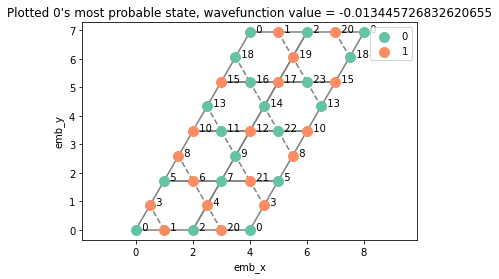

In [18]:
system = HeisenbergJ1J2(
    KagomeLattice(width=2, height=4), J1=1, J2=0, use_symmetries=True
)
system.get_eigenstates()
system.visualize_probable_configurations(m=0)

In [10]:
system.get_df_eigenstate(k=0, canonical_basis=True).sort_values("amplitude")

,eigenstate_coeff,amplitude
156404,-0.000014,0.000014
105739,-0.000014,0.000014
69271,-0.000014,0.000014
121863,-0.000014,0.000014
193232,-0.000014,0.000014
...,...,...
177713,-0.031031,0.031031
177317,-0.031031,0.031031
27251,-0.031031,0.031031
28273,-0.031031,0.031031


## Canonical basis

In [13]:
system = HeisenbergJ1J2(
    SquareLattice(width=4, height=4),
    J1=1,
    J2=0,
    use_symmetries=True,
    spin_inversion=1,
)
system.get_eigenstates()

system_nosym = HeisenbergJ1J2(
    SquareLattice(width=4, height=4),
    J1=1,
    J2=0,
    use_symmetries=False,
    spin_inversion=None,
)
system_nosym.get_eigenstates()

self.number_spins=16
Symmetry group contains 128 elements
Hilbert space dimension is 107
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-SquareLattice4x4-1.0-0.0-True-1-1.pickle
Ground state energy is -44.9139328337
self.number_spins=16
Symmetry group contains 0 elements
Hilbert space dimension is 12870
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-SquareLattice4x4-1.0-0.0-False-None-1.pickle
Ground state energy is -44.9139328337


(array([-44.91393283]),
 array([[-0.00075158],
        [-0.00134471],
        [ 0.00087267],
        ...,
        [ 0.00087267],
        [-0.00134471],
        [-0.00075158]]))

Now we compare the results of the diagonalization in the full basis with the restored ground state obtained from the basis where symmetries are taken into account. Note that the ground state is an eigenvector, so it is defined up to multiplication by a constant. We normalize it and make sure it's real, but the constant still can be either 1 or -1. So to check whether two ground states coincide, we first make first element to have the same sign by multiplying one of the vectors on -1 when necessary.

In [14]:
system_nosym.get_df_ground_state()

,eigenstate_coeff,amplitude
255,-0.000752,0.000752
383,-0.001345,0.001345
447,0.000873,0.000873
479,0.000873,0.000873
495,-0.000694,0.000694
...,...,...
65040,-0.000694,0.000694
65056,0.000873,0.000873
65088,0.000873,0.000873
65152,-0.001345,0.001345


In [15]:
system.get_df_ground_state(canonical_basis=True)

,eigenstate_coeff,amplitude
255,-0.000752,0.000752
383,-0.001345,0.001345
447,0.000873,0.000873
479,0.000873,0.000873
495,-0.000694,0.000694
...,...,...
65040,-0.000694,0.000694
65056,0.000873,0.000873
65088,0.000873,0.000873
65152,-0.001345,0.001345


In [16]:
system_nosym.get_df_ground_state()

,eigenstate_coeff,amplitude
255,-0.000752,0.000752
383,-0.001345,0.001345
447,0.000873,0.000873
479,0.000873,0.000873
495,-0.000694,0.000694
...,...,...
65040,-0.000694,0.000694
65056,0.000873,0.000873
65088,0.000873,0.000873
65152,-0.001345,0.001345


In [17]:
(
    system_nosym.get_df_ground_state()
    .join(
        system.get_df_ground_state(canonical_basis=True),
        how="outer",
        lsuffix="_x",
        rsuffix="_y",
    )
    .assign(
        ok=lambda x: np.isclose(
            x["eigenstate_coeff_x"],
            x["eigenstate_coeff_y"]
            * np.sign(x["eigenstate_coeff_y"].iloc[0])
            * np.sign(x["eigenstate_coeff_x"].iloc[0]),
        )
    )
)

,eigenstate_coeff_x,amplitude_x,eigenstate_coeff_y,amplitude_y,ok
255,-0.000752,0.000752,-0.000752,0.000752,True
383,-0.001345,0.001345,-0.001345,0.001345,True
447,0.000873,0.000873,0.000873,0.000873,True
479,0.000873,0.000873,0.000873,0.000873,True
495,-0.000694,0.000694,-0.000694,0.000694,True
...,...,...,...,...,...
65040,-0.000694,0.000694,-0.000694,0.000694,True
65056,0.000873,0.000873,0.000873,0.000873,True
65088,0.000873,0.000873,0.000873,0.000873,True
65152,-0.001345,0.001345,-0.001345,0.001345,True


In [18]:
assert (
    system_nosym.get_df_ground_state()
    .join(
        system.get_df_ground_state(canonical_basis=True),
        how="outer",
        lsuffix="_x",
        rsuffix="_y",
    )
    .assign(
        ok=lambda x: np.isclose(
            x["eigenstate_coeff_x"],
            x["eigenstate_coeff_y"]
            * np.sign(x["eigenstate_coeff_y"].iloc[0])
            * np.sign(x["eigenstate_coeff_x"].iloc[0]),
        )
    )["ok"]
    .all()
)

Order of elements in the dataframe correponds to order of elements in basis.states

In [19]:
assert (
    system.get_df_ground_state(canonical_basis=True).index
    == system.canonical_basis.states
).all()

In [20]:
assert (
    system.get_df_ground_state(canonical_basis=False).index
    == system.basis.states
).all()

In [ ]:
HeisenbergJ1J2(
    (width=12), J1=1, J2=0, use_symmetries=True
)